Introduction and general goal of this study:
The Footprint Identification Technique (FIT) is a method used to identify individual animals based on their footprints. It also enables the extraction and modeling of additional information such as the sex of the animal that left the footprint.
FIT is currently available as a free add-in for the JMP statistical software and has been custom-tailored for several endangered species. The aim of this dissertation was to establish FIT for the Eurasian otter and benchmark its classification capabilities against those previously published for other species.
This initial analysis was conducted using JMP. However, throughout the workflow, several limitations became evident—particularly regarding automation capabilities for experiments involving modified workflows and the reproducibility of annotated images.
Due to these limitations, the decision was made to transfer the methodology to a Python package, which will be open source and publicly available once the results are published.
The aim of this package is to
1.	replicate the original workflow and analyses of the JMP add-in
2.	optimize the approach for automation
3.	provide flexibility in terms of methodological components and explore whether modifications at various analysis stages lead to improved FIT models.
Although the main aim remained to develop this technique for Eurasian otters all experiments where conducted on several datasets so that the results for otters where always benchmarked with other established species. The following paragraph describes the methodology and the graphs and tables generated at each step.



In [2]:
from pathlib import Path
import sys, importlib

# Ensure the FIT_python package is importable in notebooks
# Go up exactly one level from notebooks to FIT_package
if "__file__" in globals():
    root = Path(__file__).resolve().parent.parent  # from notebooks -> FIT_package
else:
    root = Path().resolve().parent  # for Jupyter notebooks

src = root / 'src'
sys.path.insert(0, str(src))

import FIT_python.config as cfg
importlib.reload(cfg)        # recompute paths
EXP_DIR = cfg.EXPERIMENT_DIR
EXP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", root)
print("Experiment directory:", EXP_DIR)


Project root directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package
Experiment directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\experiments\dissertation_notebook


Before any train/test splits, a summary table of all analyzed datasets is generated and saved.
Columns:
• Species (Cummonn amen & Latin name) @ gtp you might need a helper dictionary here to consistently right common name and latin name (you can map species labes from the dataset to match style for a research paper)
• No. of footprints [Number of obeseravtions in df • 
No. of known individuals df[individual_id] (after renaming from the original animal coulum check load and split utils)

 No. of trails ( count df[“trails].unique
• No. of measurements ( count number of feature colums Measurements consist of any columns beginning with “V”, “Area”, “dist”, “ang” or “T”, depending on the dataset. Use existing data-loading scripts and feature definitions where possible. Be flexible for groß und kleinschreibung depindig whether data sanatize is already conducted here or not)


In [3]:
#DataImportWrapper().clean_all()

Overview generation of Datasets in experiment

In [4]:
from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview

overview_df = generate_dataset_overview(cfg.RAW_DIR, EXP_DIR/'dataset_overview.csv', reuse_csv=True)
overview_df

C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Species,No. of footprints,No. of known individuals,No. of trails,No. of measurements
0,Amur Tiger (Panthera tigris altaica),605,44,86,128
1,Bengal Tiger (Panthera tigris tigris),586,40,87,128
2,Cheetah (Acinonyx jubatus),781,38,110,135
3,Eurasian Otter (Lutra lutra),628,42,80,205
4,Giant Panda (Ailuropoda melanoleuca),523,42,77,122
5,Lowland Tapir (Tapirus terrestris),426,37,64,90
6,Mountain Lion (Puma concolor),535,35,78,131
7,White Rhinoceros (Ceratotherium simum),1273,41,154,104


Training and Test splits and inference splits
For both sex‐classification and individual‐identification models, the captive dataset of known individuals was randomly divided into training and validation subsets using a script‐based, group‐stratified sampling procedure with a fixed random seed to ensure reproducibility. Stratification guaranteed an even sex ratio across both splits, while grouping by animal prevented any overlap of individuals between training and testset.  Additional Validation folds were created and assigned and later used for hyperparameter optimization.
For the Otters a custom script for generating the folds was used making sure, that dna validated field prints only appeared in the testset, additionally since we had a set of prints in Sand and a set of prints in mud available we made sure that an equal number of individuals of both sexes are present in the testset. Train test splits needs to be executed here as it includes data cleaning steps that otherwise cause errors in the data exploration and visualisations functions that technically come beforehand in the dissertations


Splitting datasets: 100%|██████████| 8/8 [00:00<00:00, 4001.72it/s]


↪️  Verwende bestehende Splits für amur_tiger
↪️  Verwende bestehende Splits für bengal_tiger
↪️  Verwende bestehende Splits für cheetah
↪️  Verwende bestehende Splits für eurasian_otter
↪️  Verwende bestehende Splits für giant_panda
↪️  Verwende bestehende Splits für lowlandtapir
↪️  Verwende bestehende Splits für mountain_lion
↪️  Verwende bestehende Splits für white_rhino


Datasets:  12%|█▎        | 1/8 [00:00<00:03,  2.11it/s]


[DEBUG] compute_summary called for amur_tiger/inference, df shape = (0, 133)
[DEBUG] df is empty, returning empty summary

[DEBUG] compute_summary called for amur_tiger/test, df shape = (118, 133)
[DEBUG] ds_label = amur_tiger Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['panthera_tigris_altaica']
[DEBUG] species_code = panthera tigris altaica
[DEBUG] sex value counts:
sex
Female    79
Male      39
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (79, 133)
[DEBUG]  n_fp=79, n_ind=5, n_tr=11
[DEBUG]   fp_per_ind summary: mean=15.8, sd=5.844655678480983
[DEBUG]   tr_per_ind summary: mean=2.2, sd=0.7483314773547882
[DEBUG] sex = Male, subset shape = (39, 133)
[DEBUG]  n_fp=39, n_ind=4, n_tr=5
[DEBUG]   fp_per_ind summary: mean=9.75, sd=2.48746859276655
[DEBUG]   tr_per_ind summary: mean=1.25, sd=0.4330127018922193
[DEBUG] sex = Unknown, subset shape = (0, 133)
[DEBUG]  n_fp=0, n_ind=0, n_


[DEBUG] compute_summary called for bengal_tiger/inference, df shape = (38, 133)
[DEBUG] ds_label = bengal_tiger Inference
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['panthera_tigris_tigris']
[DEBUG] species_code = panthera tigris tigris
[DEBUG] sex value counts:
sex
Unknown    38
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (0, 133)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Male, subset shape = (0, 133)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] sex = Unknown, subset shape = (38, 133)
[DEBUG]  n_fp=38, n_ind=6, n_tr=7
[DEBUG]   fp_per_ind summary: mean=6.333333333333333, sd=1.9720265943665387
[DEBUG]   tr_per_ind summary: mean=1.1666666666666667, sd=0.37267799624996495
[DEBUG] Returning summary DataFrame with shape (3, 10)

[DEBUG] compute_summary called for bengal_tiger/test, 

...

Datasets:  88%|████████▊ | 7/8 [00:00<00:00, 11.45it/s]

[DEBUG] sex = Female, subset shape = (244, 139)
[DEBUG]  n_fp=244, n_ind=15, n_tr=36
[DEBUG]   fp_per_ind summary: mean=16.266666666666666, sd=4.057366414587451
[DEBUG]   tr_per_ind summary: mean=2.4, sd=0.6110100926607788
[DEBUG] sex = Male, subset shape = (190, 139)
[DEBUG]  n_fp=190, n_ind=13, n_tr=27
[DEBUG]   fp_per_ind summary: mean=14.615384615384615, sd=5.181898397876705
[DEBUG]   tr_per_ind summary: mean=2.076923076923077, sd=0.8284868934053082
[DEBUG] sex = Unknown, subset shape = (0, 139)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] Returning summary DataFrame with shape (3, 10)



[DEBUG] compute_summary called for white_rhino/inference, df shape = (0, 117)
[DEBUG] df is empty, returning empty summary

[DEBUG] compute_summary called for white_rhino/test, df shape = (213, 117)
[DEBUG] ds_label = white_rhino Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['ceratotherium_simum']
[DEBUG] species_code = ceratotherium simum
[DEBUG] sex value counts:
sex
Female    160
Male       53
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (160, 117)
[DEBUG]  n_fp=160, n_ind=5, n_tr=20
[DEBUG]   fp_per_ind summary: mean=32.0, sd=17.977764043395386
[DEBUG]   tr_per_ind summary: mean=4.4, sd=2.244994432064365
[DEBUG] sex = Male, subset shape = (53, 117)
[DEBUG]  n_fp=53, n_ind=4, n_tr=7
[DEBUG]   fp_per_ind summary: mean=13.25, sd=3.112474899497183
[DEBUG]   tr_per_ind summary: mean=1.75, sd=0.4330127018922193
[DEBUG] sex = Unknown, subset shape = (0, 117)
[DEBUG]  n_fp=0, n_ind=0, n

Datasets: 100%|██████████| 8/8 [00:00<00:00,  9.20it/s]



[DEBUG] compute_summary called for white_rhino/train, df shape = (1060, 118)
[DEBUG] ds_label = white_rhino Train
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['ceratotherium_simum']
[DEBUG] species_code = ceratotherium simum
[DEBUG] sex value counts:
sex
Male      578
Female    482
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (482, 118)
[DEBUG]  n_fp=482, n_ind=16, n_tr=60
[DEBUG]   fp_per_ind summary: mean=30.125, sd=15.846430986187395
[DEBUG]   tr_per_ind summary: mean=4.25, sd=2.0463381929681126
[DEBUG] sex = Male, subset shape = (578, 118)
[DEBUG]  n_fp=578, n_ind=16, n_tr=69
[DEBUG]   fp_per_ind summary: mean=36.125, sd=21.212835147617586
[DEBUG]   tr_per_ind summary: mean=4.9375, sd=2.461421083439402
[DEBUG] sex = Unknown, subset shape = (0, 118)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] Returning summary DataFrame with shape (3,

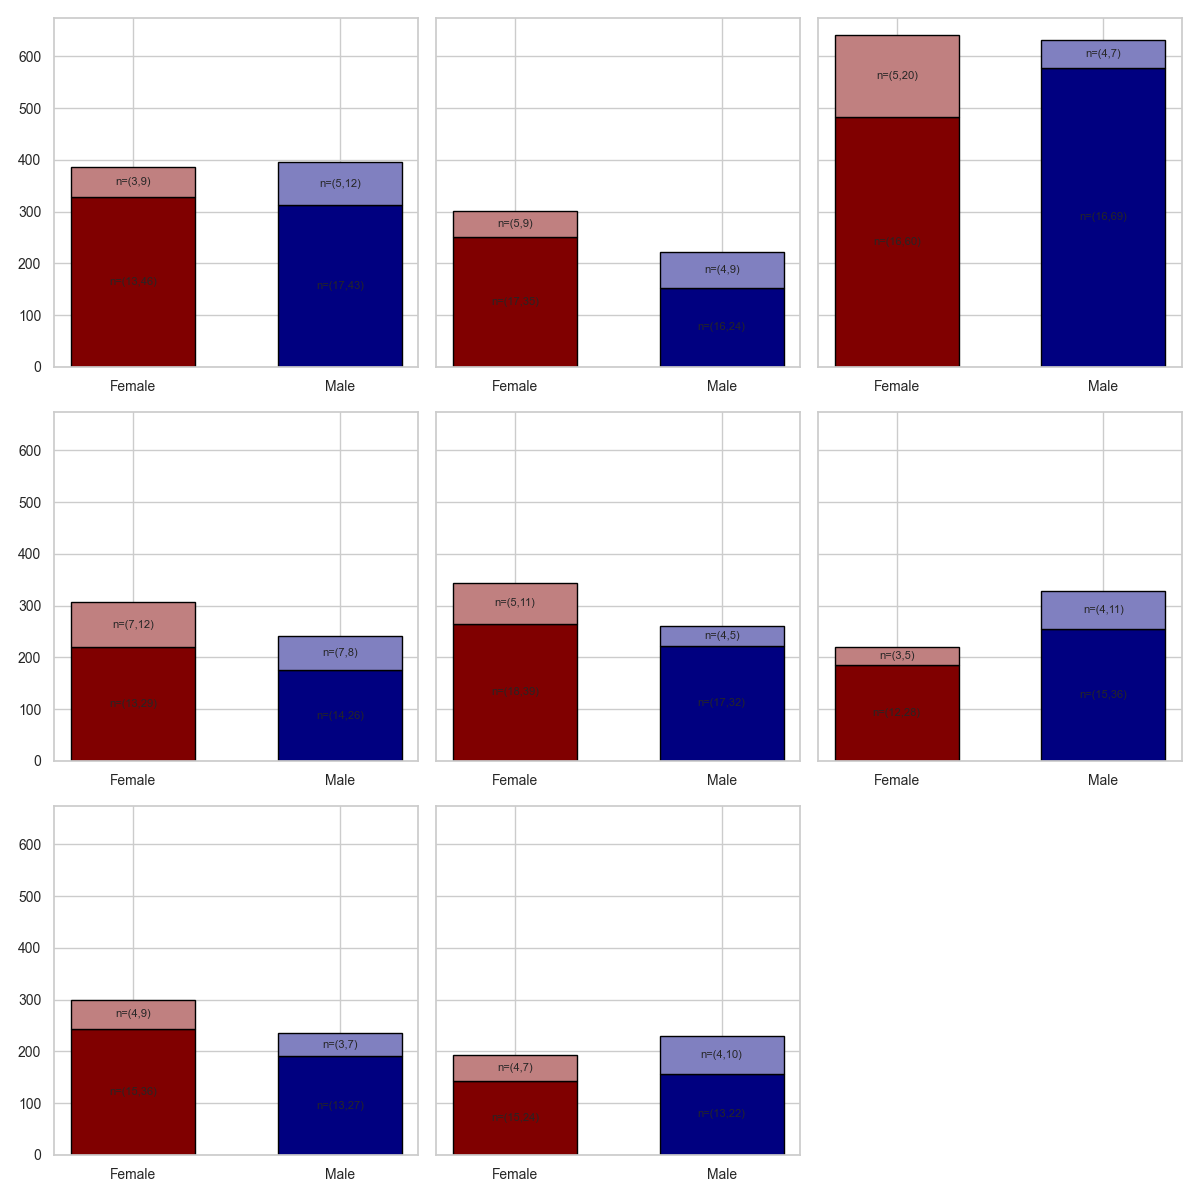

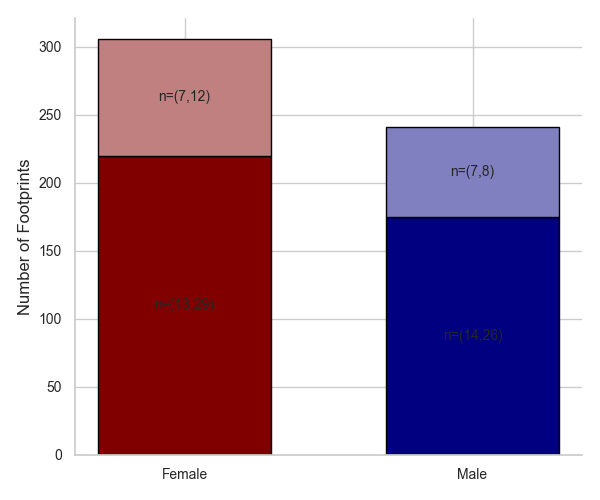

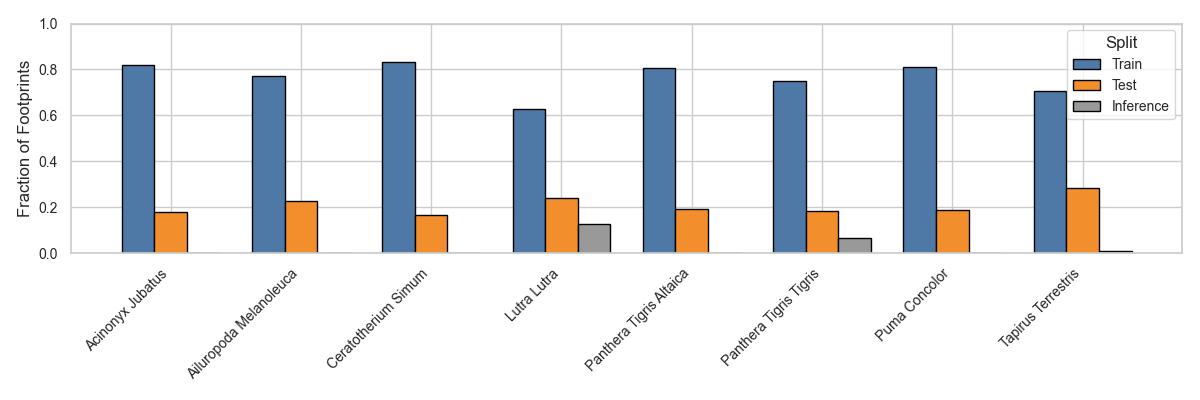

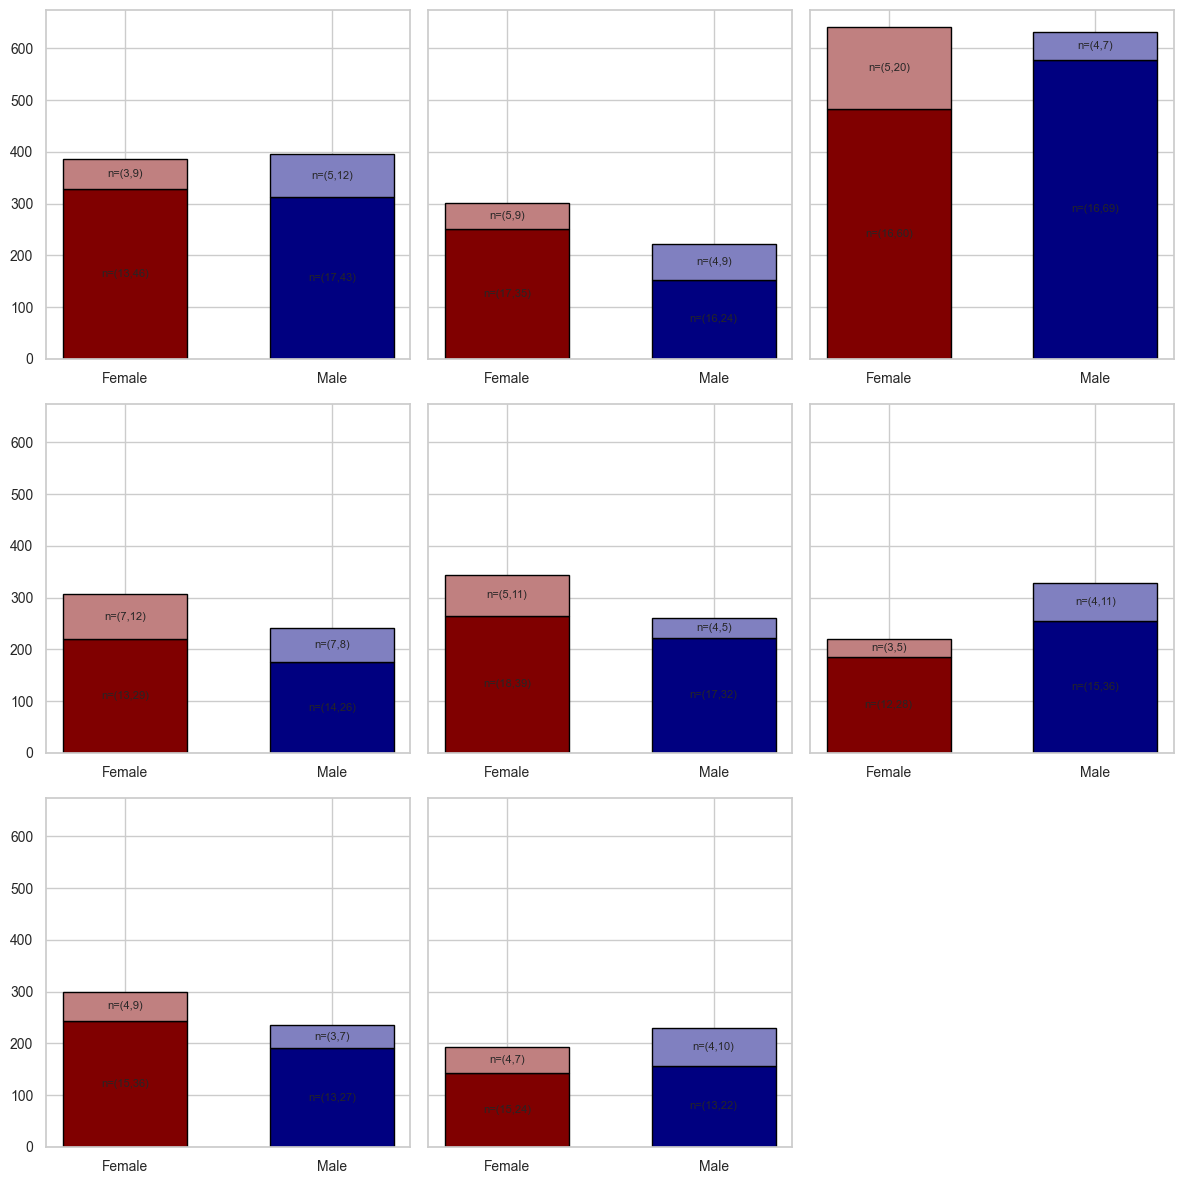

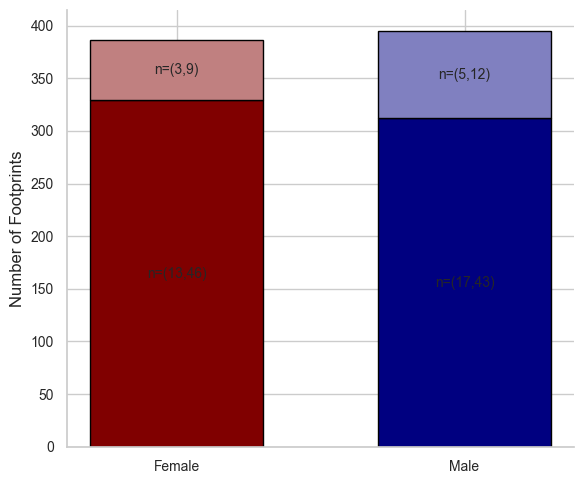

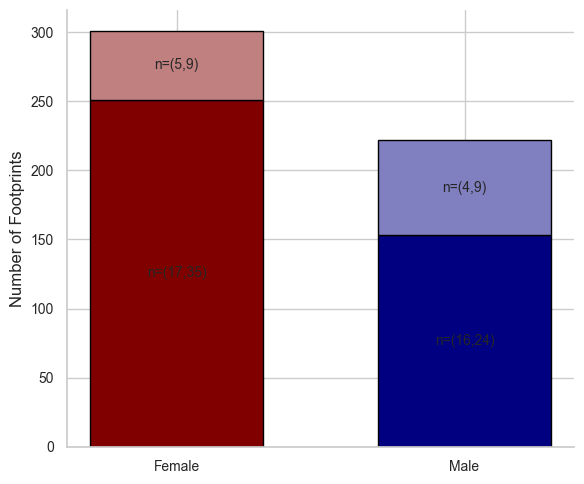

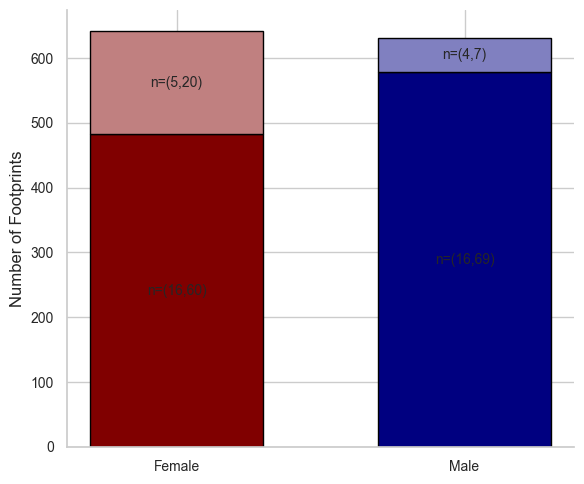

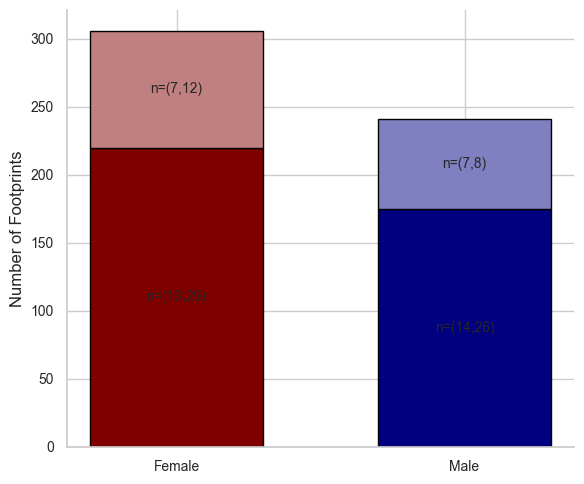

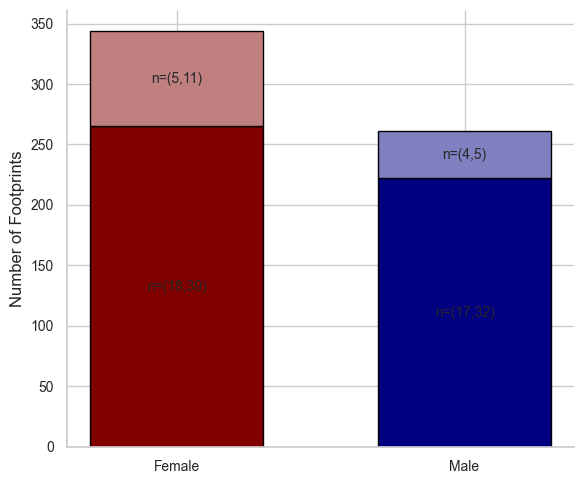

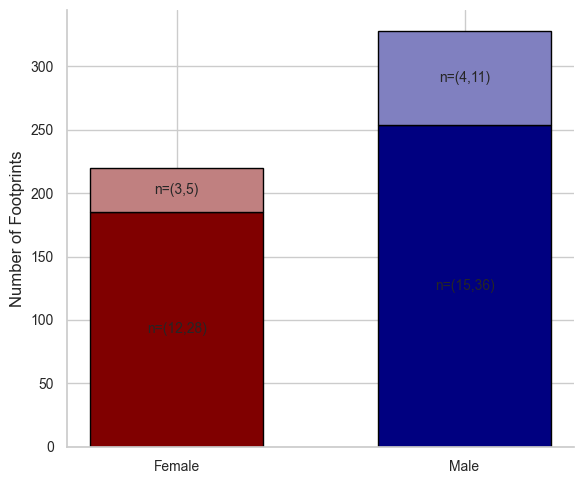

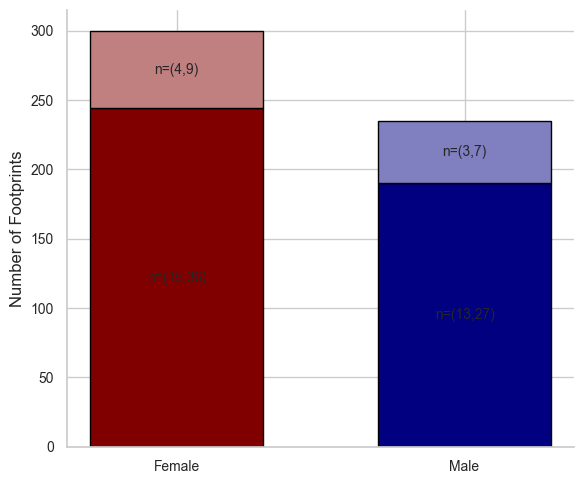

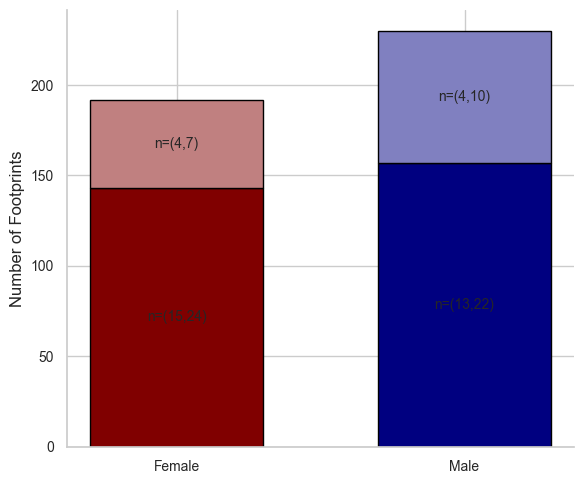

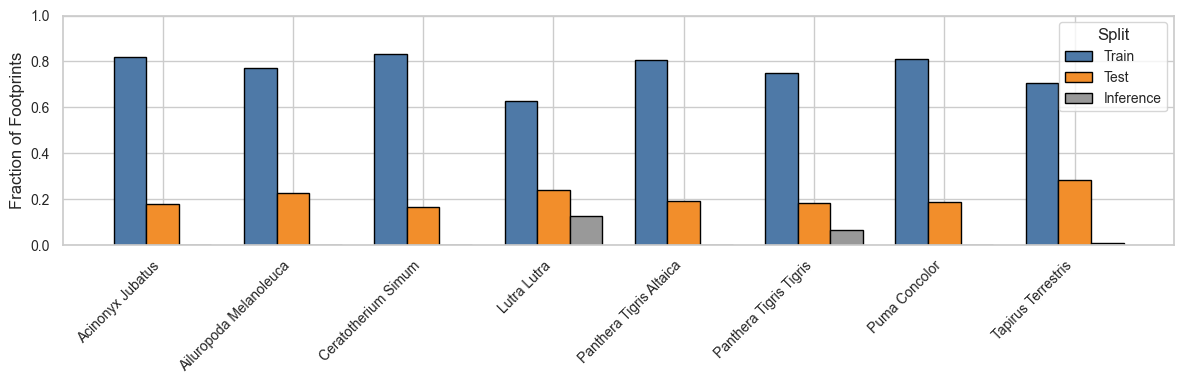

In [5]:

from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from IPython.display import Image, display
import pandas as pd
SplitWrapper().split_all(reuse_splits=True)
run_summary(cfg.SPLITS_DIR, EXP_DIR/'split_summary.csv', EXP_DIR/'split_fig')
display(Image(filename=EXP_DIR/'split_fig/summary_all.png'))
display(Image(filename=EXP_DIR/'split_fig/lutra_lutra_summary.png'))
display(Image(filename=EXP_DIR/'split_fig/split_proportions.png'))



Data Exploration (This step is performed exclusively on the otter data to keep the number of plots manageable.)
With over two hundred measurements extracted from just 11 unique landmarks, we anticipate high correlation among features. Previous FIT publications have shown that using many measurements aids individual identification. However, when the number of measurements far exceeds the number of landmarks, strong correlations between individual measurements emerge.
1.	A correlation matrix (Distances, Angles, Areas) is visualized (see “Correlation Matrix for Eurasian Otters”).
2.	We examine the top four univariate features with the highest separation power for the targets “sex” and “individual_id” on the full otter dataset.
3.	We generate two supervised UMAP embeddings—for “sex” and for “individual_id”—using fivefold cross-validation. Note that these embeddings are for visualization only; all modeling steps described later adhere to a stricter split regime.


In [6]:
from FIT_python.Visualisations.plot_style import map_sex

from FIT_python.Visualisations.plots_utils import (
    plot_feature_correlation_matrix,
    select_top_features,
    plot_sex_boxplots,
    plot_individual_boxplots,
)
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# Pfad zur Datei
file_path = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\cleaned\Eurasian_Otter.parquet")

# Unterordner für Data Exploration anlegen
exp_dir_dataexpl = EXP_DIR / "data_exploration_figures"
exp_dir_dataexpl.mkdir(parents=True, exist_ok=True)

# Laden des DataFrames
otter_df = pd.read_parquet(file_path)

otter_df = otter_df.dropna(subset=['sex', 'individual_id'])
otter_df = otter_df[~otter_df['sex'].astype(str).str.lower().eq('na')]
otter_df = otter_df[~otter_df['individual_id'].astype(str).str.lower().eq('na')]
otter_df['sex_mapped'] = map_sex(otter_df['sex'])

top_sex = select_top_features(otter_df, 'sex', k=4)
top_ind = select_top_features(otter_df, 'individual_id', k=4)


plot_feature_correlation_matrix(otter_df, exp_dir_dataexpl)
plot_sex_boxplots(otter_df, top_sex, exp_dir_dataexpl, 'sex_boxplots.png')
plot_individual_boxplots(otter_df, top_ind, exp_dir_dataexpl, 'individual_boxplots.png')



[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[CAPTION] Boxplots of features ['dist10_14', 'dist3_10', 'dist9_14', 'dist10_13'] by sex (Female, Male).
[CAPTION] Boxplots of ['dist12_14', 'dist13_15', 't2_3_5', 't12_13_15'] grouped by individual


WindowsPath('C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/experiments/dissertation_notebook/data_exploration_figures/individual_boxplots.png')

Visualisierung mit Umap alle Otter

C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Frede\AppData\Local\Temp\ipykernel_28096\4165001939.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_28096\4165001939.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_28096\4165001939.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('_').  Matplotlib is ignoring the ed

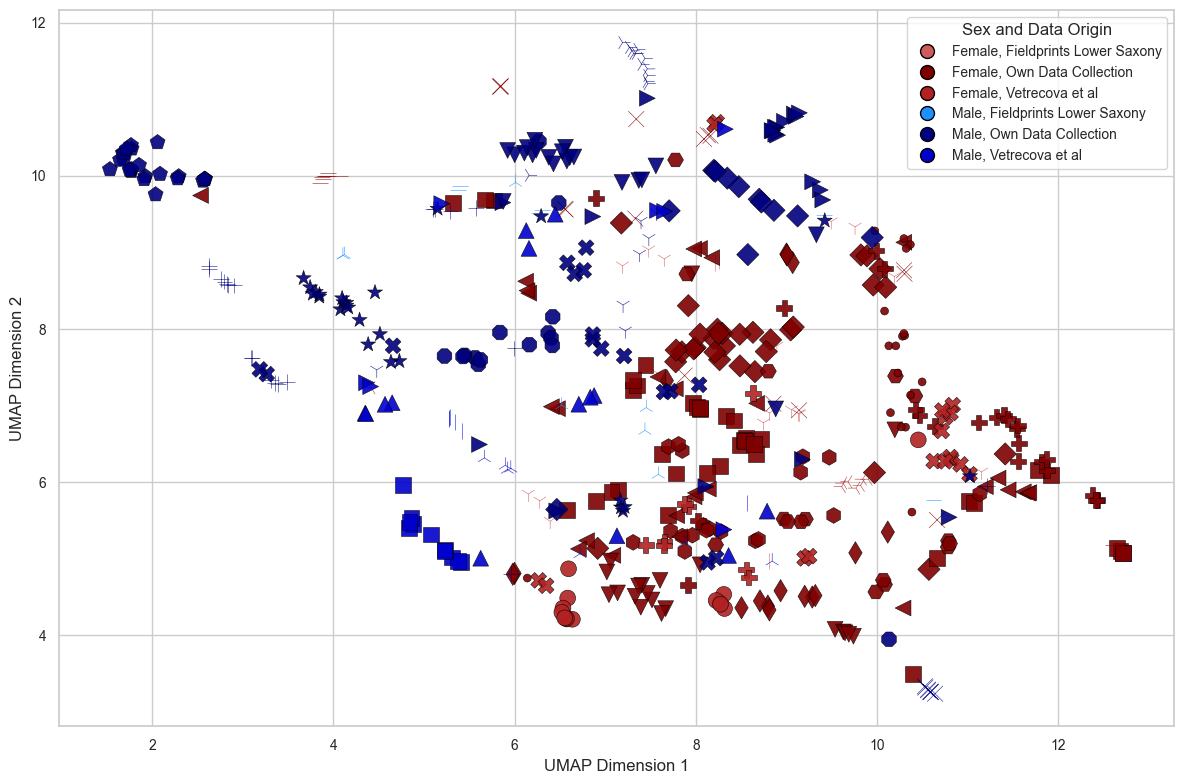

In [7]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
from matplotlib.lines import Line2D
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# --------------------------------
# Embedding erzeugen
# --------------------------------
# Nur gewünschte Dataorigins filtern
otter_df = otter_df[otter_df['dataorigin'].isin([
    'Vetrecova et al', 'Own Data Collection', 'Fieldprints Lower Saxony'
])]

# Features bestimmen und numerisch umwandeln
features = get_feature_cols(otter_df)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)

# supervised UMAP mit Individual-ID und festem Seed
dr = DimensionalityReducerTransformer(
    method='umap',
    supervised=True,
    random_state=42    # Seed für Reproduzierbarkeit
)
emb = dr.fit_transform(X, otter_df['individual_id'])

# DataFrame mit Embedding und Metadaten
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=otter_df['sex'].map({'f':'Female', 'F':'Female', 0:'Female',
                                    'm':'Male', 'M':'Male', 1:'Male'}),
    dataorigin=otter_df['dataorigin']
)
# Marker-Liste für viele Individuen
markers = ['o', 's', '^', 'v', '<', '>', 'P', 'X', 'D', '*', '+', 'x', '|', '_',
           '1', '2', '3', '4', '8', 'p', 'H', 'h', 'd', '.', ',']
marker_cycle = itertools.cycle(markers)
unique_individuals = emb_df['individual_id'].unique()
marker_map = {ind: next(marker_cycle) for ind in unique_individuals}

# Kräftigere Farbpaletten für Sex mit klareren Schattierungen
sex_palette = {
    'Female': ["#800000", "#B22222", "#CD5C5C"],   # Dunkelrot → Rot → Hellrot
    'Male': ["#000080", "#0000CD", "#1E90FF"]      # Navy → Mittelblau → Hellblau
}
origin_order = ['Own Data Collection', 'Vetrecova et al', 'Fieldprints Lower Saxony']

# Farbe zuweisen basierend auf Sex und Data Origin
def assign_color(row):
    palette = sex_palette[row['sex_mapped']]
    idx = origin_order.index(row['dataorigin']) % len(palette)
    return palette[idx]

emb_df['color'] = emb_df.apply(assign_color, axis=1)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    for ind, subgroup in group.groupby('individual_id'):
        ax.scatter(
            subgroup['UMAP1'], subgroup['UMAP2'],
            c=subgroup['color'],
            marker=marker_map[ind],
            s=130,          # Noch größere Marker
            alpha=0.9,
            edgecolor='black',
            linewidth=0.4
        )

# Achsenbeschriftungen
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")

# Legende nur mit Kreisen
from matplotlib.lines import Line2D
legend_elements = []
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    legend_elements.append(Line2D(
        [0], [0], marker='o', color='w', label=f"{sex}, {origin}",
        markerfacecolor=group['color'].iloc[0], markersize=10, markeredgecolor='black'
    ))

ax.legend(handles=legend_elements, title="Sex and Data Origin", fontsize=10)

plt.tight_layout()

# Speichern
fig_path = Path(exp_dir_dataexpl) / "umap_individuals_sex_origin_bigmarkers_simplelegend.png"
plt.savefig(fig_path, dpi=300)
plt.show()


Training sex Model

In [8]:
# ────────────────────────────────────────────────────────────────
# Sex Classification: Model Training with Bayesian Optimisation
# ────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier  # Optional, falls CatBoost aktiv
from FIT_python.pipeline_sex.sex_config import run_otter_search_sex, run_other_species_search
from FIT_python.pipeline_sex import collect_best_metrics
import FIT_python.config as cfg

# deine vorhandenen Helper
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric

# ─── Models Definition ───────────────────────────────────────────
# ─── Models Definition (LDA, Logistic Regression, XGBoost Variants) ──────────
MODELS = {
    # Logistic Regression Variants
    "logreg_l2": LogisticRegression(
        penalty="l2", solver="lbfgs", C=1.0, max_iter=500
    ),
    "logreg_l1": LogisticRegression(
        penalty="l1", solver="saga", C=1.0, max_iter=500
    ),

    # LDA Baseline
    "lda": LinearDiscriminantAnalysis(),

    # XGBoost Variants
    "xgb_std": XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_deep": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=10,
        subsample=0.9, colsample_bytree=0.9,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_fast": XGBClassifier(
        n_estimators=50, learning_rate=0.2, max_depth=4,
        subsample=0.8, colsample_bytree=0.7,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_reg": XGBClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=6,
        reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.85, colsample_bytree=0.85,
        use_label_encoder=False, verbosity=0
    ),
}
# BayesSearchCV ausführen (legt automatisch species-bezogene Unterordner an)
run_otter_search_sex()       # Otter
run_other_species_search()   # alle übrigen Spezies

# Zusammenfassung der besten Modelle für Auswertung und Visualisierung
summary_df = collect_best_metrics(cfg.RESULTS_DATA_DIR)

Best Models Ballaned accuracy , majority individual  classification , accuracy , und mean log loss For otter

✅ Benchmark-Tabelle gespeichert unter: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\experiments\dissertation_notebook\benchmark\benchmark_summary.csv


,Species,Balanced Accuracy,Accuracy,Majority Vote Accuracy,Female Accuracy,Male Accuracy
1,Amur Tiger,0.93,0.92,1.00,0.89,0.94
1,Bengal Tiger,0.90,0.90,0.86,0.90,0.76
1,Eurasian Otter,0.84,0.83,1.00,0.76,0.88
1,Giant Panda,0.81,0.78,0.78,0.96,0.52
1,Mountain Lion,0.78,0.78,0.71,0.81,0.80
1,White Rhino,0.59,0.41,0.44,0.22,0.95
1,Cheetah,0.55,0.56,0.50,0.59,0.45
1,Lowlandtapir,0.53,0.55,0.62,0.43,0.64


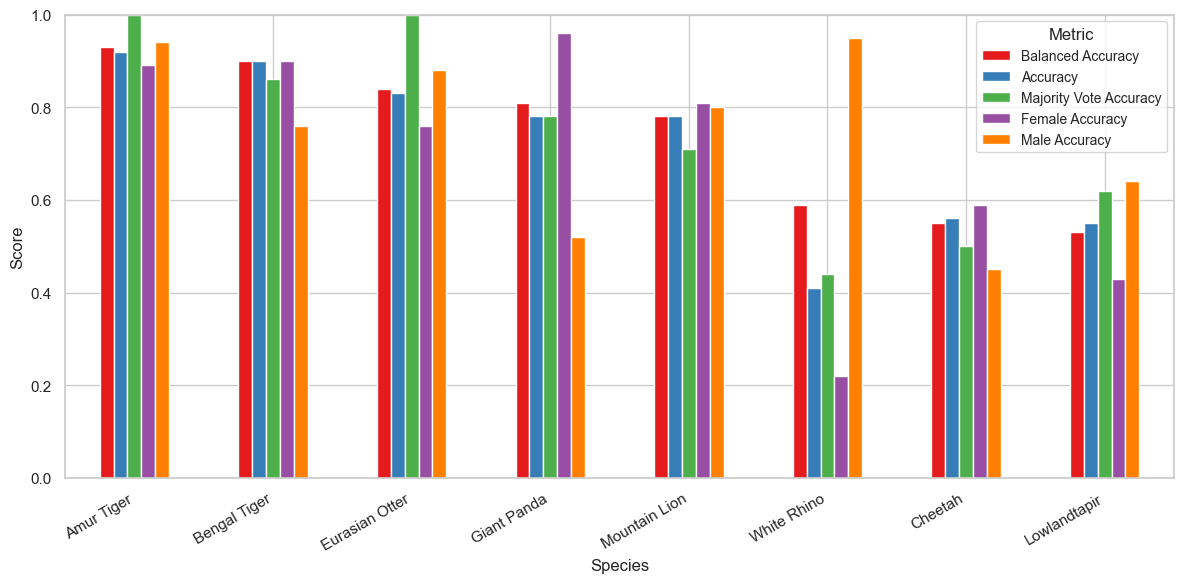

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Projekt- und Experimentverzeichnisse
project_root = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package")
exp_dir = project_root / "experiments" / "dissertation_notebook"

base_dir = exp_dir / "results" / "data"
benchmark_dir = exp_dir / "benchmark"
benchmark_dir.mkdir(parents=True, exist_ok=True)

benchmark_rows = []

for species_dir in base_dir.glob("*"):
    best_csv = species_dir / "best_models.csv"
    if best_csv.exists():
        df_best = pd.read_csv(best_csv)
        row = df_best[df_best["best_metric"] == "balanced_test_acc"]
        if not row.empty:
            benchmark_rows.append(row.iloc[0])

benchmark_df = pd.DataFrame(benchmark_rows)

# Spalten sauber benennen
col_map = {
    "species": "Species",
    "balanced_test_acc": "Balanced Accuracy",
    "accuracy_test": "Accuracy",
    "maj_test_pct": "Majority Vote Individual Accuracy",
    "female_test_acc": "Female Accuracy",
    "male_test_acc": "Male Accuracy",
}
cols_to_keep = [c for c in col_map.keys() if c in benchmark_df.columns]
benchmark_df = benchmark_df[cols_to_keep]
benchmark_df = benchmark_df.rename(columns=col_map)

# Species-Namen säubern (z.B. underscores durch Leerzeichen ersetzen, erste Buchstaben groß)
benchmark_df["Species"] = (
    benchmark_df["Species"]
    .str.replace("_", " ")
    .str.title()
)

# Runden und sortieren
benchmark_df = benchmark_df.round(2)
benchmark_df = benchmark_df.sort_values(by="Balanced Accuracy", ascending=False)

# Speichern
out_path = benchmark_dir / "benchmark_summary.csv"
benchmark_df.to_csv(out_path, index=False)
print(f"✅ Benchmark-Tabelle gespeichert unter: {out_path}")
display(benchmark_df)

# Plot mit sns Farbpalette
sns.set_style("whitegrid")
palette = sns.color_palette("Set1", n_colors=len(benchmark_df.columns) - 1)

ax = benchmark_df.set_index("Species")[list(col_map.values())[1:]].plot(
    kind="bar", figsize=(12, 6), color=palette
)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Species", fontsize=12)
ax.legend(title="Metric", fontsize=10)
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


In [10]:
from FIT_python.pipeline_sex.sex_config import run_otter_search_sex, run_other_species_search
from FIT_python.pipeline_sex import collect_best_metrics
import FIT_python.config as cfg

# BayesSearchCV ausführen (legt automatisch species-bezogene Unterordner an)
run_otter_search_sex()       # Otter
run_other_species_search()   # alle übrigen Spezies

# Zusammenfassung der besten Modelle für Auswertung und Visualisierung
summary_df = collect_best_metrics(cfg.RESULTS_DATA_DIR)

Baseline Model: Sex Classification Across Species
We employed a stepwise Linear Discriminant Analysis (LDA) classifier, a method widely used in ecological and conservation research due to its interpretability, robustness on small datasets, and successful application in similar contexts—such as a pilot study on Eurasian otters by Mercier (2004) [Mercier, 2004; Alibhai et al., 2017; Tucker et al., 2024].
Variable selection followed a stepwise procedure:
•	Forward selection: Variables with a high F-ratio and an associated p-value below 0.05 were included in the model.
•	Backward elimination: Variables with p-values above 0.05 were iteratively removed.
These steps were repeated until no further variables met the respective inclusion or exclusion criteria.
To evaluate the model's generalizability, five-fold cross-validation was performed using the validation folds of the training set generated during the initial data split. We trained with an optimization goal of a high F1 value to achieve good classification rates in both classes
The resulting LDA classifier assigned each prediction a confidence score ranging from 0 to 1, used to assess certainty. Confidence levels were defined as follows:
•	High Confidence: Confidence score > 0.9
•	Moderate Confidence: Confidence score > 0.7 and ≤ 0.9
•	Low Confidence: Confidence score ≤ 0.

Evaluation Metrics for Sex Classification
The performance of the sex classification model was assessed using multiple datasets: (1) the validation folds derived from the training set, consisting of footprints from known captive otters; (2) a test set featuring new individuals from captive environments (across both sexes) with substrate types of mud and sand; and (3) wild otters with sex confirmed through DNA analysis.
Model evaluations were conducted at two levels: the individual footprint level and the trail-level aggregation. For the trail-level assessment, predictions from individual footprints were combined via majority voting. Confidence categories for aggregated predictions adhered to the same thresholds defined for individual footprints.
Baseline models were constructed using the full multi-species dataset. A summary table was generated to compare standard machine learning metrics, including Accuracy, Balanced Accuracy, Recall, Precision, and F1 Score. In addition to standard performance metrics, two custom Python functions were implemented to provide further insight into model behavior at the individual level:
•	The individual_accuracies() function calculates average prediction accuracy for female and male otters separately, based on true labels. By computing the mean footprint-level accuracy per individual and aggregating separately across sexes, this metric allows for the comparison of classification performance between groups. The balanced accuracy is reported as the average of female and male individual accuracies.
•	The individual_majority_stats() function assesses classification success at the individual level by counting the number of individuals for whom the model correctly predicted the majority of their footprints. Specifically, if more than 50% of an individual's footprints were correctly predicted, the individual is considered correctly classified. This function returns the count of correctly and incorrectly predicted individuals, along with the proportion of correct classifications.
These individual-level metrics complement footprint-level and trail-level evaluations by providing a more nuanced understanding of model consistency and reliability across subjects.



In [11]:
#from here on use only Train sets for all further steps!!!

Individual Identification Using FIT Models (baseline Models)
FIT models classify individual animals by comparing pairs of footprint trails using pairwise stepwise \gls{lda} (LDA) \cite{jewell2016spotting}. For each pairwise comparison, a dedicated LDA model is built to maximize separation between the two trails—treated as distinct groups—and a third group known as the \gls{rcv}. For each trail pair, the number of features used to calculate the canonical variates on the x- and y-axes is first reduced by selecting a predefined number of features based on their F-ratio. 
We used the above-described raw morphometric measurements as input variables.
For each trail, least-squares means (centroids) are calculated in canonical space, and 50% confidence-circles are plotted around them. Classification is based on whether these ellipses overlap: if they do, the trails are considered to originate from the same individual (“self”); if not, they are assumed to belong to different individuals (“non-self”) \cite{alibhai2008footprint,jewell2016spotting,li2018using}.
Because the spatial relationship between centroids is sensitive to the composition of the test set, two key modifications were implemented as originally proposed by \cite{jewell2001censusing}. First, comparisons are conducted on a strictly pairwise basis, isolating each pair of test trails. Second, the \gls{rcv}, derived from the centroids of the remaining known individuals, is used as a stable geometric anchor in canonical space. This stabilizes the positioning of the test-trail centroids and ensures consistent interpretation of their relative proximity.
To evaluate model performance, classification outcomes were recorded for each of the sequential holdout splits of the train set described above. The final FIT output includes a cluster dendrogram estimating the number of individuals present in the test set. Trails predicted to originate from the same individual were grouped based on hierarchical clustering of inter-trail distances.  
Details on the clustering procedure and its use for population-size estimation are provided in Section~\ref{sec:population_estimation}.

Balanced Classification Rate as Primary Metric
Previous FIT studies commonly reported overall classification accuracies derived from confusion matrices, categorizing positives as ‘self’ classifications (matching pairs) and negatives as ‘non-self’ classifications (mismatched pairs) (Alibhai et al., 2008; Jewell et al., 2016; Li et al., 2018; Alibhai et al., 2022). However, because non-self pairwise comparisons substantially outnumber self-comparisons, overall accuracy can be misleading. To address this imbalance, we adopted the Balanced Classification Rate (BCR), following Kistner et al. (2024).
The BCR equally weights the correct classification of matching (self) and non-matching (non-self) trail pairs, providing a balanced and robust evaluation of model performance. We evaluated BCR across the entire dataset and reported the average across all steps of the sequential holdout validation.
Population Size Estimation from Footprint Trails
To estimate the number of individuals represented in a given test set, we structured the pairwise discriminant distances between trails into a distance matrix. This matrix served as input for Ward’s hierarchical clustering algorithm, which groups trails by minimizing within-cluster variance. The resulting dendrogram visualizes these groupings and enables population size estimation.
We assessed estimation accuracy using the Dendrogram Error Rate (DER), defined as the absolute difference between the Predicted Number of Animals (PNA) and the True Number of Animals (TNA), divided by TNA:
DER = PNA − TNA / TNA
Lower DER values indicate better agreement between predicted and true numbers of individuals. For methodological background and metric validation, see Kistner et al. (2024).
The resulting dendrograms were visually inspected to verify the separation of clusters and support interpretability of population size estimates.
To further assess the accuracy of population size estimates across all validation folds, we plotted predicted versus true population sizes in a scatterplot. The identity line (y = x) represents the ideal case of perfect prediction. To quantify the deviation of each regression line from this ideal, we calculated the Concordance Correlation Coefficient (CCC) as proposed by Lin (1989).
The CCC evaluates both precision (Pearson correlation) and accuracy (closeness to the identity line) in a single metric. It is defined as:
ρc = [2ρ σx σy] / [σx2 + σy2 + (μx − μy)2] Where ρ is the Pearson correlation coefficient between predicted (y) and true (x) values, and μ, σ denote the respective means and standard deviations. A CCC of ρc = 1 indicates perfect agreement, while lower values reflect increasing divergence from the ideal y = x relationship.
This metric provides a robust basis for comparing different model hyperparameter configurations with respect to their population size estimation performance.
To determine the optimal dendrogram cutoff distance for population size estimation, we leveraged the known number of individuals in the training set. For each model, we identified the cutoff distance at which Ward's hierarchical clustering produced the target number of clusters (i.e., individuals). Based on the ranked list of cluster distances, we computed the statistical confidence that alternative cutoff distances would yield the same cluster count, using a t-statistic derived from the standard error of the distance distribution.
For each model, we then defined a confidence interval around the optimal cutoff: specifically, the range of distances associated with at least 25\% probability of yielding the correct number of clusters. This interval represents the uncertainty associated with the cutoff selection and is visualized in Figure~\ref{fig:cutoff_confidence_intervals}. These model-specific cutoffs and their confidence bounds were used for subsequent population size estimation in the test data.


Notebook block7 sequential training otter:   
Only  for Otters run sequential holdouts (default individual sequence, 10 itterations) @gtp make sure pairwise comparisons are always done for the validation set ad the rcv is always used from the corresponding train set (means new pairs and new rcv for every iteration and every ssequence of the pairwise comparison).  Use the Trail column for trails and don´t generate subsamples. 
For otter find the optimal number of variables in iterating through different k values between 12 and 20 variables.
Visualize a 2x2 plot matrixs mimicking a  confusion matrix. In each cell I want visual examples of the pairs and their confidence circle either overlapping or not for cases of pairs from the same and from different animals. You probably need to write helper for that.
Visualize confusion matrix for validation folds (don´t know how to best do this sinse different datasets differ in sizes quite abit. Might make sense just to sum all individual confusion matrixes of the sequential holdout validation fold to one confusion matrix??? open to suggestion @gtp)
For every number of k. Find the optimal cutoff value for using the results of the sequential holdouts.  Otters with the above-described approaches. Plot the regression line for the predicted number of individuals for this cutoff vs the line of true number of individuals (line im ursprung mit steigung 1) .
Run the model with the best parameter for otters (number of variables k, Wards cutoff distance) for all Folds of the training set and the testset
Visualize a dendrogram for each validation fold and the test set


#Evaludation of different approaches to get best classification model